In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn import linear_model
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split


In [32]:
df = pd.read_csv('/content/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### 'Class' Column Distribution (Bar Chart) - Before Data Preprocessing

We are visualizing the distribution of the `Class` column (which is our target variable) using a bar chart. This will give us an idea of the number of legitimate and fraudulent transactions, and highlight the data imbalance.

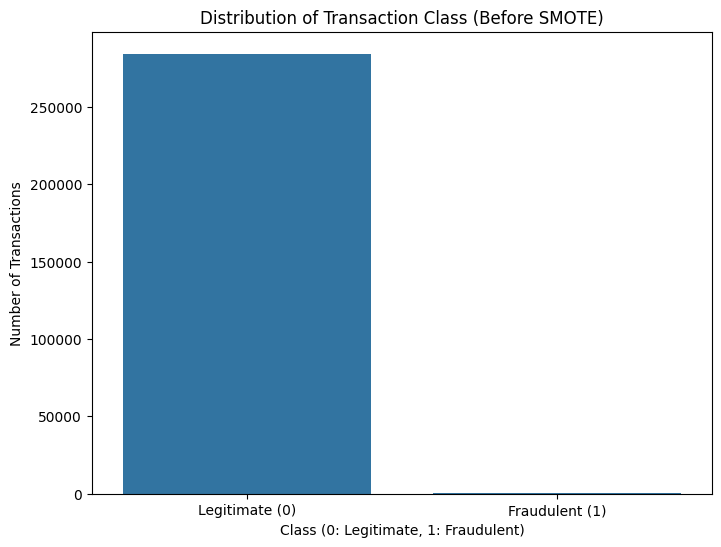

In [33]:


plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Transaction Class (Before SMOTE)')
plt.xlabel('Class (0: Legitimate, 1: Fraudulent)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraudulent (1)'])
plt.show()

In [38]:
# To check imbalancement of dataframe ,in this dataframe fraudulant payments
# data is less than ligitimate payments data.so we neeed to fix it before machine learning
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [34]:
print(df.shape)
print('\n',df.info())

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [35]:
df.isnull().sum().sum()

np.int64(0)

In [36]:
df.dropna()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [37]:
print(df.isnull().sum())


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Handling Imbalanced Data with SMOTE

Since our dataset is highly imbalanced (many more non-fraudulent transactions than fraudulent ones), a model trained directly on this data might perform poorly on the minority class (fraudulent transactions). We will use **SMOTE (Synthetic Minority Over-sampling Technique)** to oversample the minority class and balance the dataset.

In [39]:
# First, let's separate the features (X) and the target variable (y)
X = df.drop('Class', axis=1)
y = df['Class']

# We need to drop the 'Time' column from features for SMOTE(Synthetic Minority Over-sampling Technique) as it's a datetime object
# and SMOTE expects numerical data. We'll decide how to use 'Time' later if needed.
X = X.drop('Time', axis=1)
z = df['Time']

print('Original feature set shape:', X.shape)
print('Original target set shape:', y.shape)
print('Original Time feature set shape:', z.shape)

Original feature set shape: (284807, 29)
Original target set shape: (284807,)
Original Time feature set shape: (284807,)


In [40]:
# Install imbalanced-learn library if not already installed
!pip install imbalanced-learn

# Import SMOTE
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_res, y_res = sm.fit_resample(X, y)

print('Resampled feature set shape:', X_res.shape)
print('Resampled target set shape:', y_res.shape)

print('\nNew class distribution after SMOTE:')
print(y_res.value_counts())

Resampled feature set shape: (568630, 29)
Resampled target set shape: (568630,)

New class distribution after SMOTE:
Class
0    284315
1    284315
Name: count, dtype: int64


As you can see, after applying SMOTE, both classes now have an equal number of samples (284,315 each), addressing the imbalance. This balanced dataset (`X_res`, `y_res`) can now be used for training a more robust machine learning model.

### SMOTE (Synthetic Minority Over-sampling Technique) Explained

SMOTE (Synthetic Minority Over-sampling Technique) is a very popular and effective method for handling imbalanced data. In this, we create new, synthetic samples for the minority class (such as fraudulent transactions). It does not simply copy existing samples, as happens in 'Random Over-sampling'. Instead, SMOTE generates new samples by interpolating (i.e., creating new points between samples) in the feature space between samples of the minority class.

**How it works:**
1.  **Nearest Neighbors Selection:** SMOTE identifies the 'k' nearest neighbors for each sample in the minority class.
2.  **Synthetic Sample Generation:** Then, it randomly chooses one of these neighbors. And draws a line between the original sample and the chosen neighbor. New synthetic samples are randomly created along this line.

**Benefits:**
*   **Prevents Overfitting:** Since new samples are created, it does not simply replicate data, which prevents the model from overfitting.
*   **Better Generalization:** It better represents the distribution of the minority class, allowing the model to learn the patterns of the minority class more effectively.
*   **Decision Boundary Improvement:** With the creation of new samples, the decision boundary becomes clearer and more balanced.

### Outliers (Anomalous Data Points) and SMOTE

As a Data Scientist, detecting and handling outliers (anomalous data points) before applying SMOTE can indeed be an important consideration. The reasons for this are:

*   **SMOTE's effect on Outliers:** If outliers are present in the minority class, SMOTE might generate new synthetic samples based on these outliers. These new synthetic samples could also become outliers or pull the model's decision boundary towards them, which can degrade our model's performance.
*   **Incorrect Patterns:** This can lead the model to learn incorrect patterns, where it might treat these anomalous points as typical minority class features.

**However, this requires some thought process:**
1.  **Definition of an Outlier:** In cases like fraud detection, fraudulent transactions themselves are often 'outliers'. They differ from legitimate transactions, and this is their characteristic. If we indiscriminately remove them, we might lose important information.
2.  **Impact of Pre-processing:** In our dataset, features `V1` to `V28` have been transformed using PCA (Principal Component Analysis). PCA can sometimes reduce the impact of outliers to some extent, but it doesn't eliminate them completely.
3.  **'Amount' Column:** Currently, there might be outliers in the 'Amount' column, where very low or very high amounts could be indicators of fraud.

**What should be done?**
Generally, examining outliers before applying SMOTE is a good practice. We can use methods like Box Plots, Z-Score, IQR Method, or Isolation Forest to detect them. Then, to handle them, they can either be removed (if they are data entry errors and very few in number), or they can be winsorized/capped (i.e., restricted to a certain range).

**Current Situation:**
We have already balanced `X_res` and `y_res` using SMOTE. If you wish, we can explore outliers in the **'Amount'** column, or you can proceed directly to model training. This depends on your project goals and domain knowledge regarding the importance of outliers.

In [42]:
df = pd.concat([z,X_res, y_res], axis=1)
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,NaN,-4.401331,1.662285,-6.941884,4.879644,-5.081860,0.009492,-3.386245,1.412588,-3.250366,...,0.697857,0.486672,1.215460,-0.532200,0.388465,-0.009042,2.280602,0.075180,648.214807,1
568626,NaN,-3.352917,0.753401,-1.698278,0.863169,-1.186314,-0.406322,-1.652498,0.020940,-0.018209,...,0.342796,0.454379,-0.130009,-0.499223,-0.042935,0.987288,-1.389017,0.750979,101.500000,1
568627,NaN,-1.564143,1.428824,-0.924170,1.519906,-0.873001,-0.597239,-1.893836,0.566848,-1.199565,...,0.627154,0.605191,-0.187337,-0.265952,0.376297,-0.316963,-0.228888,-0.069672,19.577597,1
568628,NaN,0.735622,-0.207872,-2.800054,1.202564,-0.334384,-1.255962,0.399713,-0.248019,0.603603,...,0.107356,-0.168074,-0.151374,-0.326656,-0.009685,-0.572405,0.067883,0.009869,358.668889,1


### Outlier Detection in 'Amount' Feature

We are going to detect outliers present in the `Amount` column. Outliers are data points that are significantly different from the rest of the data and can sometimes affect the performance of a model.

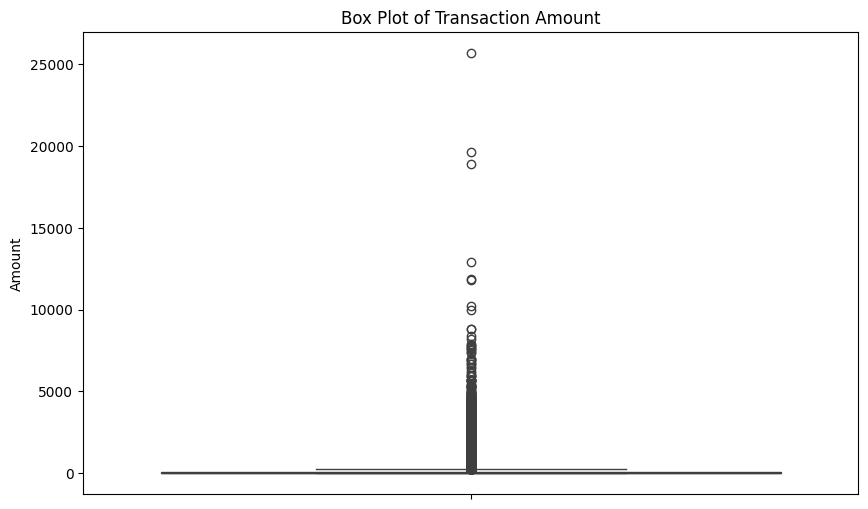

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot for the 'Amount' column to visually detect outliers
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Amount'])
plt.title('Box Plot of Transaction Amount')
plt.ylabel('Amount')
plt.show()


From the box plot, we can see many outliers in the `Amount` column. Now, let's numerically detect them using the IQR (Interquartile Range) method.

In [44]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'Amount'
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR (Interquartile Range): {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")
print(f"Number of outliers in 'Amount' column: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers) / len(df) * 100:.2f}%")

# Display some of the outliers
print('\nFirst 5 Outlier transactions:')
display(outliers.head())

Q1 (25th percentile): 1.49
Q3 (75th percentile): 99.99
IQR (Interquartile Range): 98.50
Lower Bound for Outliers: -146.26
Upper Bound for Outliers: 247.74
Number of outliers in 'Amount' column: 65553
Percentage of outliers: 11.53%

First 5 Outlier transactions:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
51,36.0,-1.004929,-0.985978,-0.038039,3.710061,-6.631951,5.122103,4.371691,-2.006868,-0.278736,...,1.393406,-0.381671,0.969719,0.019445,0.570923,0.333278,0.857373,-0.075538,1402.95,0
89,59.0,-0.773293,-4.146007,-0.932038,0.027094,-1.698307,0.460188,0.737344,-0.314216,-0.842673,...,0.890978,0.026123,-1.134769,-0.654958,0.098386,-0.209150,-0.171709,0.208057,1142.02,0
134,83.0,-1.897331,0.955626,0.052543,1.276656,-3.323084,3.229911,1.029631,1.515607,-0.059627,...,0.128416,0.776078,0.477537,-0.608981,-1.120892,-0.413851,0.061399,-0.187964,552.18,0
140,87.0,-5.101877,1.897022,-3.458034,-1.277543,-5.517758,2.098366,3.329603,1.250966,0.271501,...,-0.871744,-0.678879,-0.555900,-0.761660,0.066611,0.767227,0.731634,-0.860310,919.60,0


As we have seen, the `Amount` feature contains a significant number of outliers. Now we have a few options:

1.  **Remove outliers:** If these outliers are data entry errors or irrelevant to our analysis, we can remove them. However, in fraud detection, high `Amount` transactions could be fraudulent, so removing them might not be a good option.
2.  **Cap outliers (Winsorization):** Restrict them to a specific range. That is, replace values greater than the upper bound with the upper bound, and values less than the lower bound with the lower bound. This way, we control the extremes while maintaining data integrity.
3.  **Transform outliers:** Such as performing a log transformation (logarithmic transformation) to normalize the data distribution and reduce the impact of outliers.
4.  **Leave them as they are:** If our model is robust to outliers or if the outliers themselves are indicators of our target (fraud).

Which approach to adopt depends on your project goals and domain knowledge. For now, these outliers have been identified.

```


### Capping Outliers (Winsorization)

We will cap the outliers present in the `Amount` column. This means that values greater than the `upper_bound` will be set to the `upper_bound`, and values less than the `lower_bound` will be set to the `lower_bound`. This way, we will control the extremes while maintaining data integrity.

Original Amount Statistics:


,Amount
count,568630.000000
mean,104.661529
std,250.831789
min,0.000000
25%,1.490821
50%,18.600000
75%,99.990000
max,25691.160000



Capped Amount Statistics:


,Amount_Capped
count,568630.000000
mean,63.326184
std,84.350268
min,0.000000
25%,1.490821
50%,18.600000
75%,99.990000
max,247.738769


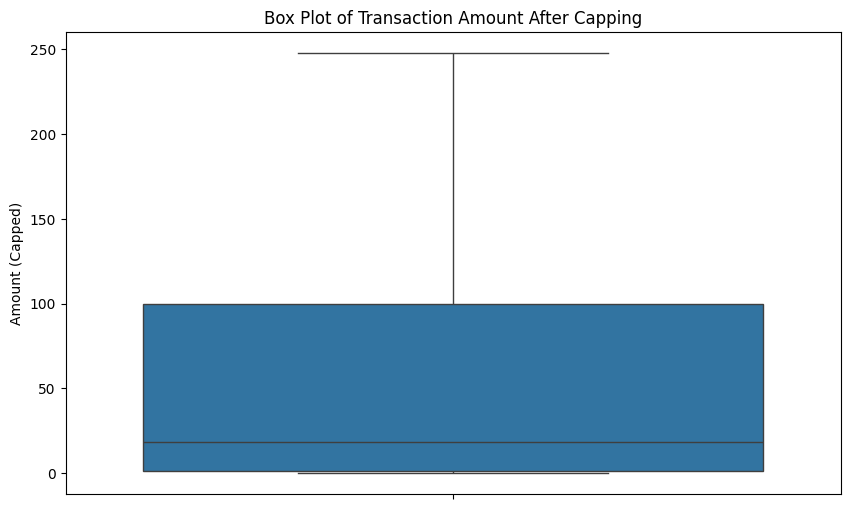

In [45]:
# Apply Winsorization (Capping) to the 'Amount' column
df['Amount_Capped'] = df['Amount'].clip(lower=lower_bound, upper=upper_bound)

# Display the statistics of the original and capped 'Amount' column
print('Original Amount Statistics:')
display(df['Amount'].describe())

print('\nCapped Amount Statistics:')
display(df['Amount_Capped'].describe())

# Visualize the distribution after capping
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Amount_Capped'])
plt.title('Box Plot of Transaction Amount After Capping')
plt.ylabel('Amount (Capped)')
plt.show()

As you can see, after capping, the `Amount_Capped` column now has controlled extreme values, and the impact of outliers in the box plot has been significantly reduced. You can now use this `Amount_Capped` feature for your model training.

In [46]:
# Separate the Target variable (y) from the Predictors (X)
X = df.drop('Class', axis=1)
y = df['Class']

# Split data: 80% for training and 20% for unseen testing
# stratify=y ensures the percentage of people who left is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
# Standardize features by removing the mean and scaling to unit variance
# This ensures all features (like satisfaction vs. hours) are on the same scale
scaler = StandardScaler()

# Fit and transform only on the training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data using the training parameters
X_test_scaled = scaler.transform(X_test)


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [49]:
# Predict on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

print("---------- RANDOM FOREST PERFORMANCE ----------")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")

print("\n---------- CONFUSION MATRIX ----------")
print(confusion_matrix(y_test, y_pred_rf))

print("\n---------- DETAILED CLASSIFICATION REPORT ----------")
print(classification_report(y_test, y_pred_rf))

---------- RANDOM FOREST PERFORMANCE ----------
Overall Accuracy: 99.98%

---------- CONFUSION MATRIX ----------
[[56859     4]
 [   18 56845]]

---------- DETAILED CLASSIFICATION REPORT ----------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [52]:
from sklearn.metrics import average_precision_score
auprc = average_precision_score(y_test, y_pred_rf)
print(f'AUPRC Score: {auprc}')

AUPRC Score: 0.9997713852847607
